# 1. Load Thư Viện

In [ ]:
import json, sys, random, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import PIL
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Activation
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Conv2D, MaxPooling2D,ZeroPadding2D
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.initializers import glorot_uniform
from tensorflow.keras.utils import plot_model
from PIL import Image, ImageDraw
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from os import listdir
import time
import math
import shutil
from tqdm import tqdm
from tensorflow.keras.preprocessing import image

from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import RMSprop

# Kiểm tra GPU
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 2. DATA PREPROCESSING AND DATA ANALYSIS

In [ ]:
#Lớp dùng để tăng cường dữ liệu (data augmentation) và chuẩn hóa ảnh trước khi đưa vào model.
train_datagen = ImageDataGenerator(
        rescale=1./255, # Chia tất cả giá trị pixel từ [0, 255] về [0, 1]
        shear_range=0.2,# Biến dạng (shear) ảnh theo góc (giúp model học tốt hơn)
        zoom_range=0.2,  # Phóng to / thu nhỏ ngẫu nhiên ảnh
        horizontal_flip=True) # Lật ngang ảnh ngẫu nhiên

# Validation và test chỉ chuẩn hóa (rescale) chứ không augmentation để giữ dữ liệu đánh giá trung thực.
val_datagen = ImageDataGenerator(rescale = 1./255)
test_datagen = ImageDataGenerator(rescale = 1./255)

# Phương thức này đọc ảnh từ thư mục, chia batch, và gắn nhãn dựa trên tên thư mục con.
# train sẽ là một data generator để huấn luyện model.
train = train_datagen.flow_from_directory(
        '/content/drive/MyDrive/Colab Notebooks/DataSet/training_set',
        target_size=(224, 224), # Resize toàn bộ ảnh về 224x224 pixel
        batch_size=32,           # Mỗi lần sinh 32 ảnh
        class_mode='binary')    # Vì bài toán phân loại 2 lớp → dùng binary
# test generator dùng cho đánh giá trên tập test.
test = test_datagen.flow_from_directory(
        '/content/drive/MyDrive/Colab Notebooks/DataSet/test_set',
        target_size=(224, 224),
        batch_size=32,
        class_mode='binary')
# validation generator dùng để kiểm tra hiệu suất model trong khi huấn luyện (validation accuracy/loss).
validation = val_datagen.flow_from_directory(
        '/content/drive/MyDrive/Colab Notebooks/DataSet/validation_set',
        target_size=(224, 224),
        batch_size=32,
        class_mode='binary')

Found 560 images belonging to 2 classes.
Found 240 images belonging to 2 classes.
Found 160 images belonging to 2 classes.


In [ ]:
print(train.class_indices)
print(test.class_indices)
print(validation.class_indices)

{'hemmorhage_data': 0, 'non_hemmorhage_data': 1}
{'hemmorhage_data': 0, 'non_hemmorhage_data': 1}
{'hemmorhage_data': 0, 'non_hemmorhage_data': 1}


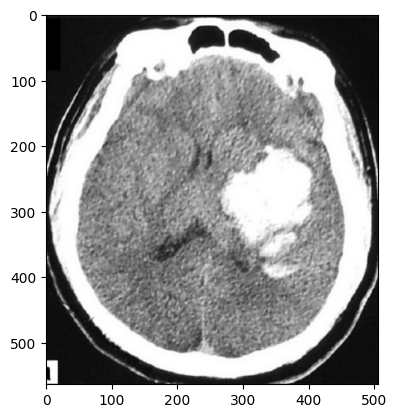

In [ ]:
# plt.imread(path) trả về một mảng NumPy chứa dữ liệu pixel:
# Nhận mảng ảnh (array) từ plt.imread() và hiển thị ra cửa sổ đồ họa.
plt.imshow(plt.imread("/content/drive/MyDrive/Colab Notebooks/DataSet/training_set/hemmorhage_data/030.png"))

# 3. Load MobileNetV3 pre-trained
tf.keras.applications.MobileNetV3Large(

    input_shape=None, # Kích thước ảnh đầu vào (cao, rộng, số kênh).
    alpha=1.0, # Hệ số nhân độ rộng (số kênh) của mạng
    minimalistic=False, # bỏ bớt SE blocks, chỉ dùng kernel 3×3
    include_top=True, # Có giữ nguyên phần fully-connected cuối cùng của MobileNetV3 không
    weights="imagenet", # Trọng số pretrained để khởi tạo model.
    input_tensor=None, # Truyền tensor đầu vào tùy chỉnh (thường dùng khi kết hợp nhiều mạng).
    classes=1000, # Số lớp phân loại ở đầu ra
    pooling=None,
    dropout_rate=0.2, # Tỉ lệ dropout ở phần fully-connected để tránh overfitting
    classifier_activation="softmax" # Hàm kích hoạt của lớp Dense cuối cùng

)

In [ ]:
from tensorflow.keras import layers as L
IMG_SIZE = (224, 224)
BATCH = 32
SEED  = 1337

In [ ]:
# Tải MobileNetV3 pretrained
base_model = tf.keras.applications.MobileNetV3Small(
    input_shape=IMG_SIZE+(3,),# (kiểu tuple có 1 phần tử)
    include_top=False,
    weights='imagenet',
    include_preprocessing=False  # ta sẽ tự preprocess về [-1,1]
)

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
base_model.trainable = False # We freeze the training of the convolutions
#base_model.summary()

# 4. Tạo Model

In [ ]:
# pipeline
# Ảnh → base_model (trích đặc trưng) → GAP (nén đặc trưng) → Dropout → Dense(sigmoid) → xác suất bị bệnh hay không.
model = models.Sequential([
    base_model, # Đây là mạng CNN đã được huấn luyện sẵn (pretrained) trên ImageNet.
    layers.GlobalAveragePooling2D(), # Thay vì Flatten toàn bộ feature map (có thể hàng ngàn giá trị), GAP sẽ tính trung bình toàn bộ giá trị trên mỗi channel → giảm số lượng tham số rất nhiều.
    layers.Dropout(0.3), # Ngẫu nhiên tắt đi 30% neuron trong quá trình training.
    layers.Dense(1, activation="sigmoid")  # Binary classification
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3), # dùng Adam optimizer với learning rate 1e-3 = 0.001
    loss="binary_crossentropy", # Hàm mất mát (loss function) cho bài toán phân loại nhị phân.
    metrics=[tf.keras.metrics.AUC(name="auc"), "accuracy"] # Đây là các chỉ số đánh giá mô hình trong quá trình training/validation.
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 939,697 (3.58 MB)

 Trainable params: 577 (2.25 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [ ]:
es = EarlyStopping(monitor='val_accuracy',min_delta= 0.01 ,  patience= 2, verbose= 2, mode='auto')
mc = ModelCheckpoint(filepath="/content/drive/MyDrive/Colab Notebooks/MobileNetV3/best_modelV3.keras",monitor='val_accuracy',save_best_only = True )
model.fit(x=train,validation_data=validation,epochs=5,callbacks = [mc,es], steps_per_epoch=50)

# Test

In [ ]:
print(model.evaluate(test))

In [ ]:
model_best = tf.keras.models.load_model("/content/drive/MyDrive/Colab Notebooks/MobileNetV3/best_modelV3.keras")

In [ ]:
model_best.evaluate(test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 578ms/step - accuracy: 0.8591 - auc: 0.9278 - loss: 0.4485


[0.4573633074760437, 0.9192014336585999, 0.8500000238418579]

In [ ]:
test.class_indices

{'hemmorhage_data': 0, 'non_hemmorhage_data': 1}

In [ ]:
def predictor(path):
    img = image.load_img(path, target_size=(224,224),) # Dùng Keras Image để load ảnh từ path
    i = image.img_to_array(img)/255 # Chuyển ảnh thành numpy array (dạng tensor 3 chiều: (224,224,3)) rồi chuẩn hóa pixel từ [0,255] → [0,1].
    input_arr = np.array([i])      #Thêm một chiều batch → thành (1,224,224,3) để model nhận input.
    input_arr.shape
    pred = model_best.predict(input_arr)[0][0] # Chạy dự đoán với model đã lưu (model_best)
    if pred < 0.5:
        print("The MRI image is of BRAIN TUMOR")
    else:
        print("The MRI image is of HEALTHY BRAIN WITHOUT TUMOR")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
The MRI image is of BRAIN TUMOR
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
The MRI image is of BRAIN TUMOR
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
The MRI image is of BRAIN TUMOR
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
The MRI image is of BRAIN TUMOR
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
The MRI image is of BRAIN TUMOR
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
The MRI image is of HEALTHY BRAIN WITHOUT TUMOR
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
The MRI image is of HEALTHY BRAIN WITHOUT TUMOR
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
The MRI image is of HEALTHY BRAIN WITHOUT TUMOR
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
The MRI image is of HEALTHY BRAIN WITHOUT TUMOR
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
The MRI image is of HEALTHY BRAIN WITHOUT TUMOR


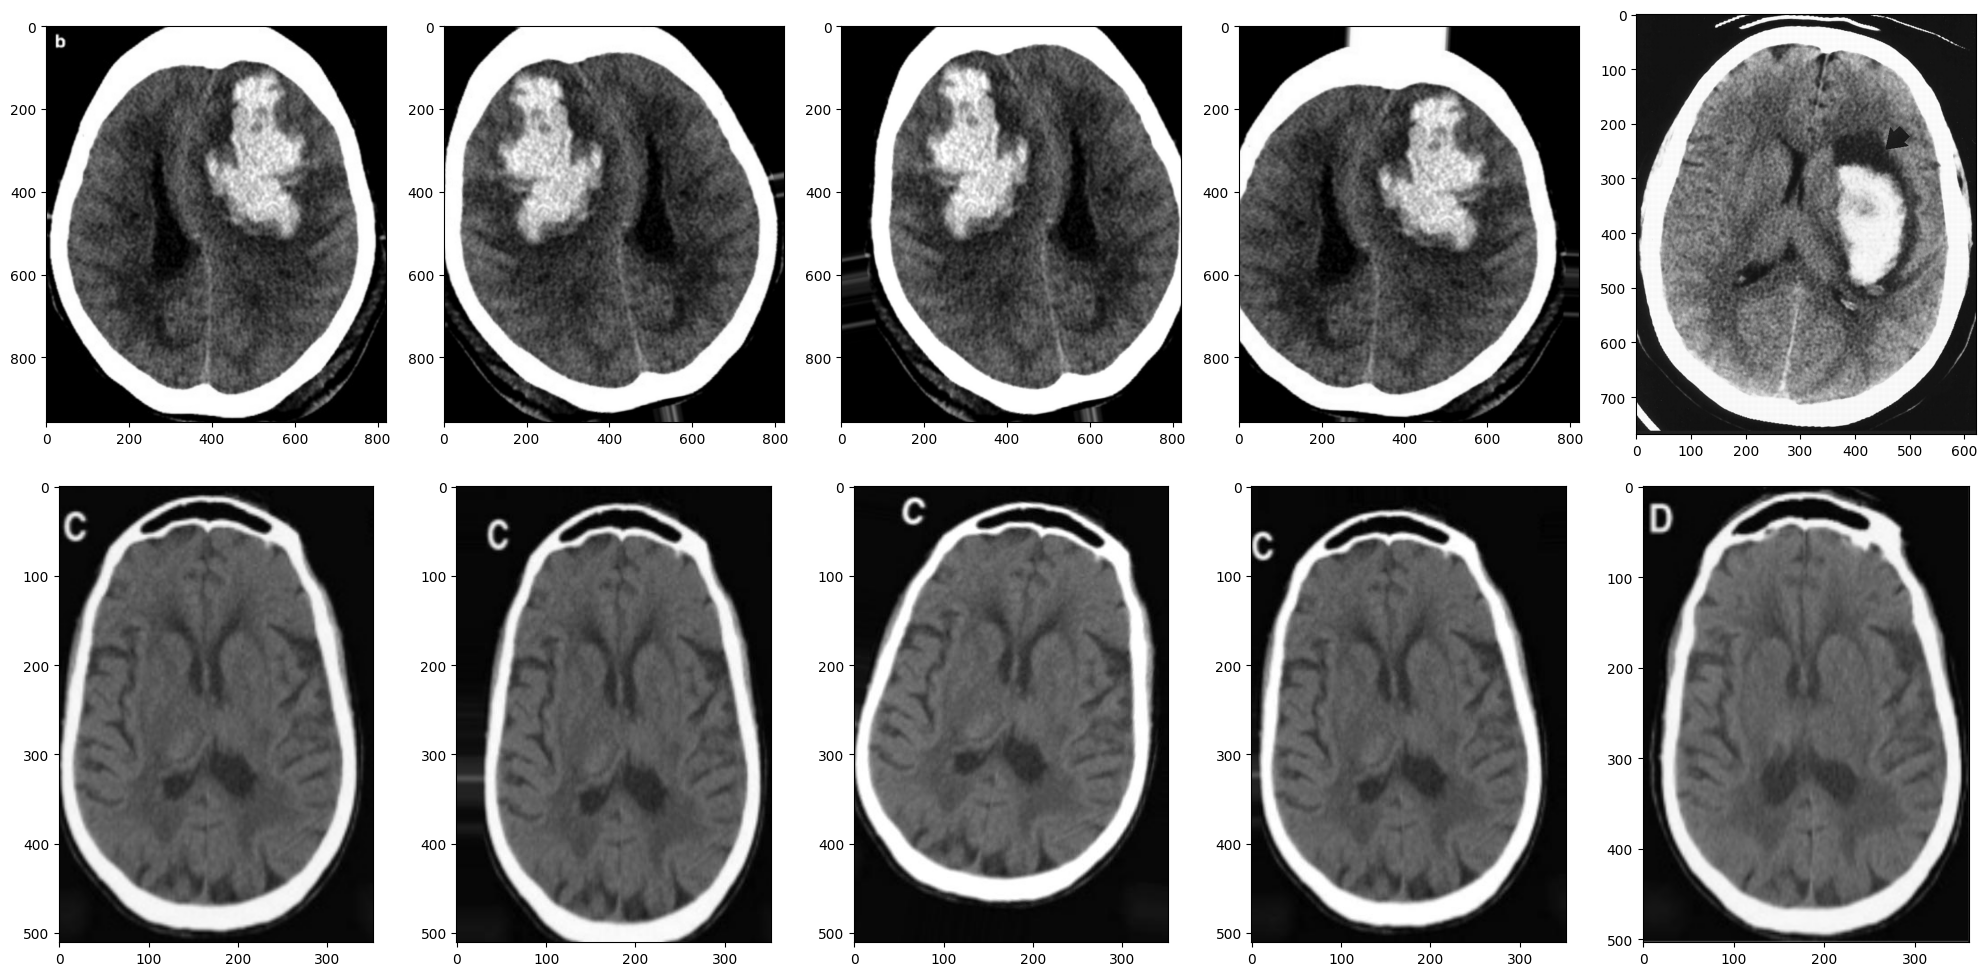

In [ ]:
fig, axs = plt.subplots(2, 5, figsize=(20, 10))
lst =["/content/drive/MyDrive/Colab Notebooks/DataSet/test_set/hemmorhage_data/000.png",
      "/content/drive/MyDrive/Colab Notebooks/DataSet/test_set/hemmorhage_data/000_0_4951.jpg",
      "/content/drive/MyDrive/Colab Notebooks/DataSet/test_set/hemmorhage_data/000_0_5016.jpg",
      "/content/drive/MyDrive/Colab Notebooks/DataSet/test_set/hemmorhage_data/000_0_6311.jpg",
 "/content/drive/MyDrive/Colab Notebooks/DataSet/test_set/hemmorhage_data/001.png",
           "/content/drive/MyDrive/Colab Notebooks/DataSet/test_set/non_hemmorhage_data/100.png",
      "/content/drive/MyDrive/Colab Notebooks/DataSet/test_set/non_hemmorhage_data/100_0_3927.jpg",
      "/content/drive/MyDrive/Colab Notebooks/DataSet/test_set/non_hemmorhage_data/100_0_4059.jpg",
      "/content/drive/MyDrive/Colab Notebooks/DataSet/test_set/non_hemmorhage_data/100_0_5853.jpg",
      "/content/drive/MyDrive/Colab Notebooks/DataSet/test_set/non_hemmorhage_data/101.png"
]
axs[0][0].title.set_text(predictor(lst[0]))
axs[0][0].imshow(PIL.Image.open(lst[0]))
axs[0][1].title.set_text(predictor(lst[1]))
axs[0][1].imshow(PIL.Image.open(lst[1]))
axs[0][2].title.set_text(predictor(lst[2]))
axs[0][2].imshow(PIL.Image.open(lst[2]))
axs[0][3].title.set_text(predictor(lst[3]))
axs[0][3].imshow(PIL.Image.open(lst[3]))
axs[0][4].title.set_text(predictor(lst[4]))
axs[0][4].imshow(PIL.Image.open(lst[4]))
axs[1][0].title.set_text(predictor(lst[5]))
axs[1][0].imshow(PIL.Image.open(lst[5]))
axs[1][1].title.set_text(predictor(lst[6]))
axs[1][1].imshow(PIL.Image.open(lst[6]))
axs[1][2].title.set_text(predictor(lst[7]))
axs[1][2].imshow(PIL.Image.open(lst[7]))
axs[1][3].title.set_text(predictor(lst[8]))
axs[1][3].imshow(PIL.Image.open(lst[8]))
axs[1][4].title.set_text(predictor(lst[9]))
axs[1][4].imshow(PIL.Image.open(lst[9]))
fig.tight_layout()